In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf

In [3]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [4]:
tf.keras.utils.set_random_seed(42)

# Dataset Loading

In [5]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [6]:
train_images, test_images = train_images / 255.0, test_images / 255.0

In [7]:
print(f"Train set {train_images.shape}, {train_labels.shape}")
print(f"Test set {test_images.shape}, {test_labels.shape}")

Train set (50000, 32, 32, 3), (50000, 1)
Test set (10000, 32, 32, 3), (10000, 1)


In [8]:
val_images, test_images, val_labels, test_labels = train_test_split(test_images, test_labels, test_size=0.5, random_state=42)

In [9]:
print(f"Train set {train_images.shape}, {train_labels.shape}")
print(f"Test set {test_images.shape}, {test_labels.shape}")
print(f"Validation set {val_images.shape}, {val_labels.shape}")

Train set (50000, 32, 32, 3), (50000, 1)
Test set (5000, 32, 32, 3), (5000, 1)
Validation set (5000, 32, 32, 3), (5000, 1)


In [10]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [11]:
# print the images

In [12]:
models_to_train = {}

# Model A

In [33]:
model_a = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(64, (5, 5), activation='relu', padding='same'), # layers.Conv2D(64, (5, 5), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.Conv2D(128, (5, 5), activation='relu', padding='same'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(256, (5, 5), activation='relu', padding='same'),
    layers.Conv2D(256, (5, 5), activation='relu', padding='same'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(512, (5, 5), activation='relu', padding='same'),
    layers.Conv2D(512, (5, 5), activation='relu', padding='same'),
    layers.MaxPool2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10)
])

In [14]:
model_a.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [15]:
print(model_a.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 512)      │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,599,306 (55.69 MB)

 Trainable params: 14,599,306 (55.69 MB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
model_a2 = models.Sequential([
    layers.Conv2D(64, (5, 5), activation='relu', padding='valid', input_shape=(32, 32, 3)),      # 28, 28
    layers.Conv2D(128, (5, 5), activation='relu', padding='valid'), # 24, 24
    layers.MaxPool2D((2, 2)), # 12, 12

    layers.Conv2D(256, (5, 5), activation='relu', padding='valid'), # 8, 8
    layers.Conv2D(256, (5, 5), activation='relu', padding='valid'), # 4, 4
    layers.MaxPool2D((2, 2)), # 2, 2

    layers.Conv2D(512, (5, 5), activation='relu', padding='valid'),
    layers.Conv2D(512, (5, 5), activation='relu', padding='valid'),
    layers.MaxPool2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Computed output size would be negative. Received `inputs shape=(None, 2, 2, 256)`, `kernel shape=(5, 5, 256, 512)`, `dilation_rate=[1 1]`.

In [17]:
model_a3 = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),      # layers.Input(shape=(32, 32, 3))
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    #layers.MaxPool2D((2, 2)),

    layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    #layers.MaxPool2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10)
])

# Model B

In [18]:
model_b = models.Sequential([
    layers.Conv2D(32, (2, 2), activation='relu', padding='valid', input_shape=(32, 32, 3)),
    layers.Conv2D(64, (2, 2), activation='relu', padding='valid'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(128, (2, 2), activation='relu', padding='valid'),
    layers.Conv2D(128, (2, 2), activation='relu', padding='valid'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(256, (2, 2), activation='relu', padding='valid'),
    layers.Conv2D(256, (2, 2), activation='relu', padding='valid'),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10)
])

In [19]:
model_b.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [20]:
print(model_b.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 31, 31, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 30, 30, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 13, 13, 128)    │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 5, 5, 256)      │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 256)      │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 633,450 (2.42 MB)

 Trainable params: 633,450 (2.42 MB)

 Non-trainable params: 0 (0.00 B)

None


# Model C

In [21]:
model_c1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10)
])

In [22]:
model_c1.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [23]:
print(model_c1.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,436,554 (16.92 MB)

 Trainable params: 4,436,554 (16.92 MB)

 Non-trainable params: 0 (0.00 B)

None


In [24]:
model_c = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', strides=(2, 2), padding='same', input_shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', strides=(2, 2), padding='same'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', strides=(2, 2), padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', strides=(2, 2), padding='same'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10)
])

In [25]:
model_c.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [26]:
print(model_c.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 1, 1, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,634 (1010.29 KB)

 Trainable params: 258,634 (1010.29 KB)

 Non-trainable params: 0 (0.00 B)

None


# Training

In [27]:
models_to_train['Model A'] = model_a
models_to_train['Model B'] = model_b
models_to_train['Model C'] = model_c

In [28]:
histories = {}

In [29]:
for model_name, model in models_to_train.items():
  print(f"\nTraining the mode: {model_name}")
  history = model.fit(train_images, train_labels, epochs=8, validation_data=(val_images, val_labels))
  histories[model_name] = history


Training the mode: Model A
Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 109s 62ms/step - accuracy: 0.0975 - loss: 2.3093 - val_accuracy: 0.1022 - val_loss: 2.3026
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.0984 - loss: 2.3028 - val_accuracy: 0.1022 - val_loss: 2.3026
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.0981 - loss: 2.3028 - val_accuracy: 0.1022 - val_loss: 2.3026
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 56ms/step - accuracy: 0.0984 - loss: 2.3028 - val_accuracy: 0.1022 - val_loss: 2.3026
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 55ms/step - accuracy: 0.0978 - loss: 2.3028 - val_accuracy: 0.1022 - val_loss: 2.3026
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.0977 - loss: 2.3028 - val_accuracy: 0.1022 - val_loss: 2.3026
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.0978 - loss: 2.3028 - val_accuracy: 0.1022 - val_loss: 2.3026
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 57ms/step

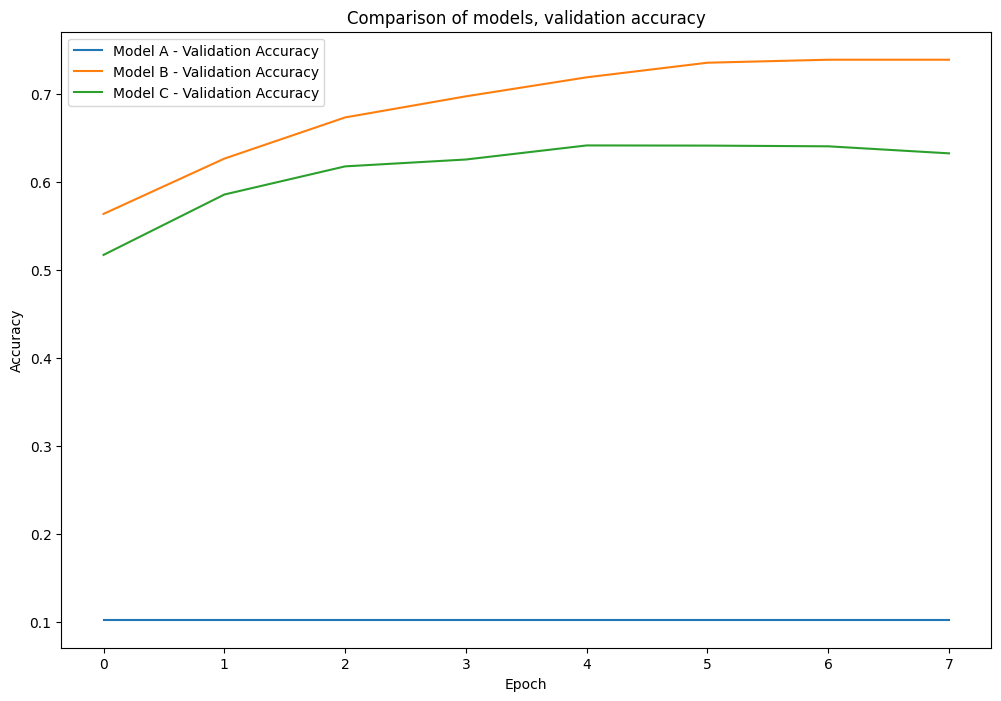

In [32]:
plt.figure(figsize=(12, 8))
for model_name, history in histories.items():
  plt.plot(history.history['val_accuracy'], label=f'{model_name} - Validation Accuracy')

plt.title("Comparison of models, validation accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [35]:
print(f'{'Model':<10} {'Params':>12} {'Test Acc':>10}')
for name, m in models_to_train.items():
  _, acc = m.evaluate(test_images, test_labels, verbose=1)
  print(f'{name:<10} {m.count_params(): > 12} {acc:>10.4f}')

Model            Params   Test Acc
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.0978 - loss: 2.3027
Model A        14599306     0.0978
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7410 - loss: 0.8506
Model B          633450     0.7410
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6380 - loss: 1.1718
Model C          258634     0.6380


Model A is too deep with too-large kernels and no batch normalization. There are 6 conv layers, each with 5×5 kernels, ReLU activations, going up to 512 filters. With ReLU and no normalization, deep networks like this often have all activations collapse to zero (the "dying ReLU" problem) — and once an activation is 0, its gradient is 0, and nothing updates.


Compared to Model B (smaller kernels, fewer parameters in the last block) and Model C (strided downsampling, only 4 conv layers) — both train fine.